#Harman Hothi (917604942)

# ECI 115: Homework 7

## <font color='red'>**Problem 28.24**</font>

An environmental engineer is interested in estimating the mixing that occurs between a stratified lake and an adjacent embayment (Fig. P28.24). A conservative tracer is instantaneously mixed with the bay water, and then the tracer concentration is monitored over the ensuing period in all three segments. The values are

|  $t$  |  0  |  2 |  4 | 6  | 8  | 12 | 16 | 20 |
|:-----:|:---:|:--:|:--:|----|----|----|----|----|
| $c_1$ |  0  | 15 | 11 | 7  | 6  | 3  | 2  | 1  |
| $c_2$ | 0   | 3  | 5  | 7  | 7  | 6  | 4  | 2  |
| $c_3$ | 100 | 48 | 26 | 16 | 10 | 4  | 3  | 2  |

Using mass balances, the system can be modeled as the following simultaneous ODEs:

$V_1\frac{dc_1}{dt}=-Qc_1+E_{12}(c_2-c_1)+E_{13}(c_3-c_1)$

$V_2\frac{dc_2}{dt}=E_{12}(c_1-c_2)$

$V_3\frac{dc_3}{dt}=E_{13}(c_1-c_3)$

where $V_i=$ volume of segment $i$, $Q=$ flow, and $E_{ij}=$ diffusive mixing rate between segments $i$ and $j$. Use the data and the differential equations to estimate the $E$'s if $V_1=1\times10^7$, $V_2=8\times10^6$, $V_3=5\times10^6$, and $Q=4 \times 10^6$. Employ Euler's method with a step size of 0.1 for your analysis.

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW7_Fig.P28.24.png?raw=true" alt="Fig. P28.24">
</p>

<font color='red'> **TL;DR**:
Explain how we can solve for the parameters $E_{12}$ and $E_{13}$ by comparing Euler's Method to the data presented in the table above using the Sum of Squared Residuals method and create a program that computes these values (Hint: you will want to use the `minimize` function in the `scipy.optimize` package). Once you have values for $E_{12}$ and $E_{13}$, print those values and create plots that compare numerical simulations for $c_1$, $c_2$, and $c_3$ as a function of time to the data provided in the table above (on separate plots). Discuss the results and potential reasons for discrepancies between the model and the data.
</font>

### <font color='blue'>**Solution 28.24**</font>

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 9.936433258619992
        x: [ 1.008e+06  2.279e+06]
      nit: 9
      jac: [-2.027e-05 -4.768e-07]
 hess_inv: [[ 3.486e+04  5.822e+06]
            [ 5.822e+06  9.723e+08]]
     nfev: 243
     njev: 77


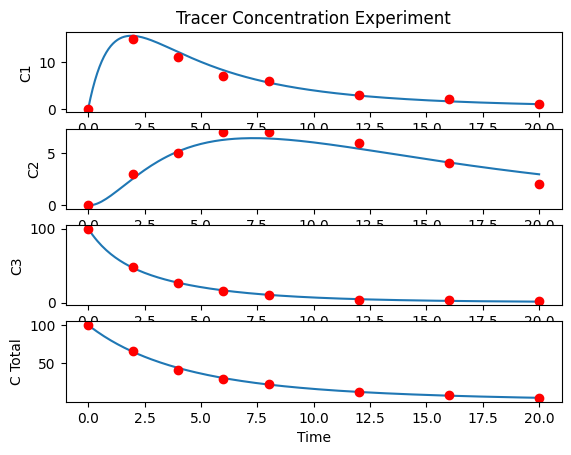

In [11]:
import numpy as np
import matplotlib.pyplot as plt
# observed data
t_obs  = np.array([0,2,4,6,8,12,16,20])
c1_obs = np.array([0,15,11,7,6,3,2,1])
c2_obs = np.array([0,3,5,7,7,6,4,2])
c3_obs = np.array([100,48,26,16,10,4,3,2])

# Define constants
V1 = 1e7
V2 = 8e6
V3 = 5e6
Q  = 4e6
dt = 0.1

# Initialize simulation arrays
t = np.arange(t_obs[0],t_obs[-1]+dt,dt)

# Define rate of change functions
def dc1dt(c1,c2,c3,params):
  E12, E13 = params
  return(-Q*c1 + E12*(c2-c1) + E13*(c3-c1)) / V1

def dc2dt(c1,c2, params):
  E12, E13 = params
  return (E12*(c1-c2)) / V2

def dc3dt(c1,c3, params):
  E12, E13 = params
  return (E13*(c1-c3)) / V3

  # follow setup from L14 parameter estimation
# for each set of input parameters, run Euler's method
# return sum of squared errors
# a guess-and-test approach would be ok but not full credit (-1 point)
def Sr(x):
  c1 = np.zeros(len(t))
  c2 = np.zeros(len(t))
  c3 = np.zeros(len(t))
  c1[0] = c1_obs[0]
  c2[0] = c2_obs[0]
  c3[0] = c3_obs[0]
  for i in range(len(t)-1):
    c1[i+1] = c1[i]+dc1dt(c1[i],c2[i],c3[i], x)*dt
    c2[i+1] = c2[i]+dc2dt(c1[i],c2[i], x)*dt
    c3[i+1] = c3[i]+dc3dt(c1[i],c3[i], x)*dt

  ti = (t_obs/dt).astype(int)
  ssr1 = np.sum((c1[ti] - c1_obs) **2)
  ssr2 = np.sum((c2[ti] - c2_obs) **2)
  ssr3 = np.sum((c3[ti] - c3_obs) **2)

  return ssr1+ssr2+ssr3

from scipy.optimize import minimize
res = minimize(Sr, x0=[10**6, 10**6])
print(res)
# the E12, E13 values are stored in res.x

# solve one more time using best-fit parameters
# and plot
# (the problem does not require a plot, but there should be
# some kind of comparison of the best-fit model to the observations.
# this could also be a table.)
c1 = np.zeros(len(t))
c2 = np.zeros(len(t))
c3 = np.zeros(len(t))
c1[0] = c1_obs[0]
c2[0] = c2_obs[0]
c3[0] = c3_obs[0]

for i in range(len(t)-1):
   c1[i+1] = c1[i]+dc1dt(c1[i],c2[i],c3[i], res.x)*dt
   c2[i+1] = c2[i]+dc2dt(c1[i],c2[i], res.x)*dt
   c3[i+1] = c3[i]+dc3dt(c1[i],c3[i], res.x)*dt

plt.subplot(4, 1, 1)
plt.plot(t,c1,label='c1')
plt.plot(t_obs,c1_obs,'o',color='r',label='c1 act')
plt.title('Tracer Concentration Experiment')
plt.xlabel('Time')
plt.ylabel('C1')
plt.subplot(4, 1, 2)
plt.plot(t,c2,label='c2')
plt.plot(t_obs,c2_obs,'o',color='r',label='c2 act')
plt.xlabel('Time')
plt.ylabel('C2')

plt.subplot(4, 1, 3)
plt.plot(t,c3,label='c3')
plt.plot(t_obs,c3_obs,'o',color='r',label='c3 act')
plt.xlabel('Time')
plt.ylabel('C3')

plt.subplot(4, 1, 4)
plt.plot(t,c1+c2+c3,label='c total')
plt.plot(t_obs,(c1_obs+c2_obs+c3_obs),'o',color='r',label='c totalact act')
plt.xlabel('Time')
plt.ylabel('C Total')
plt.show()



**Discussion of Results**

[We can estimate the parameters E12 and E13 by chossing trial values and using Euler's Method to simulate how the concentrations c1,c2, and c3 change over time. Next the simulated values are compared to the measured data in the table and the differences between the predicted and observed values are calculated using the Sum of Squared Residuals (SSR) which adds the squared errors for all the data points. The minimize function from scipy.optimize automatically tests different values of E12 and E13 until it finds the combination that gives the smallest SSR.

The results show that E12 = 1.008 * 10^6 and E13 = 2.270 * 10^6.  The plots show that the model follows the observed data very well and captures the overall trends of the concentration curves. Also small differences between the model and the data can happen because Euler's Method is an approximation and the step size may introduce numerical error.  It's also to be noted that the model simplifies the real physical process. There are also measurement errors in the experimental data that may contribute to these differences.
 ]

## <font color='red'>**Problem 28.33**</font>

Engineers and scientists use mass-spring models to gain insight into the dynamics of structures under the influence of disturbances such as earthquakes. Figure P28.33 shows such a representation for a three-story building. For this case, the analysis is limited to horizontal motion of the structure. Force balances can be developed for this system as

$\big( \frac{k_1+k_2}{m_1}-\omega^2 \big)X_1 - \frac{k_2}{m_1} X_2=0$

$-\frac{k_2}{m_2}X_1+\big( \frac{k_2+k_3}{m_2} - \omega^2 \big)X_2-\frac{k_3}{m_2}X_3=0$

$-\frac{k_3}{m_3}X_2+\big( \frac{k_3}{m_3} - \omega^2 \big)X_3=0$

Determine the eigenvalues and eigenvectors and graphically represent the modes of vibration for the structure by displaying the amplitudes versus height for each of the eigenvectors. Normalize the amplitudes so that the displacement of the third floor is 1.

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW7_Fig.P28.33.png?raw=true" alt="Fig. P28.33">
</p>

<font color='red'> **TL;DR**:
Explain how to convert the system of equations in a matrix form that would allow for us to solve for the system's eigenvalues and eigenvectors. Create a program that solves for the eigenvalues and eignvectors (Hint: use the `np.linalg.eig()` function) and plots the amplitude at each level for each eigenmode (i.e., the resulting displacement at each level when plugging in each eigenvector). For these plots, normalize the displacement so that the displacement at the third floor is 1. Discuss the physical significance of the three modes that were calculated.
</font>

### <font color='blue'>**Solution 28.33**</font>

[[ 450. -200.    0.]
 [-240.  420. -180.]
 [   0. -225.  225.]]
Eigenvalues:  [698.59819018 339.47788688  56.92392295]
Eigenvectors:
 [[-0.58785405 -0.63435541  0.29129699]
 [ 0.73069726 -0.3505515   0.57250939]
 [-0.34714424  0.68898973  0.76640659]]
[26.43100812 18.4249257   7.54479443]
[[ 1.69339998 -0.92070373  0.38008153]
 [-2.10488085 -0.50879061  0.74700479]
 [ 1.          1.          1.        ]]


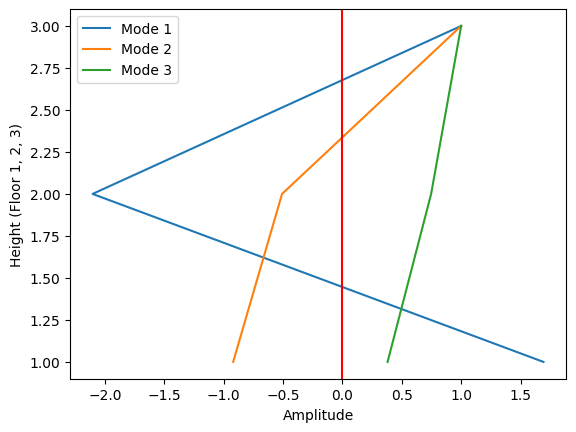

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# given values
m1, m2, m3 = 12000, 10000, 8000
k1, k2, k3 = 3000e3, 2400e3, 1800e3

# system matrix
A = np.array([
    [(k1 + k2)/m1,   -k2/m1,        0],
    [   -k2/m2,   (k2 + k3)/m2,  -k3/m2],
    [      0,        -k3/m3,      k3/m3]
], dtype=float)

print(A)

# eigenvalue problem
eigvals, eigvecs = np.linalg.eig(A)
print('Eigenvalues: ', eigvals)
print('Eigenvectors:\n', eigvecs)

# natural frequencies
omega = np.sqrt(eigvals)
print(omega)

# normalize each mode shape by 3rd-floor displacement
modes = eigvecs.copy()
for j in range(modes.shape[1]):
    modes[:, j] = modes[:, j] / modes[2, j]

print(modes)

# plot mode shapes
floors = np.array([1, 2, 3])

for j in range(3):
    plt.plot(modes[:, j], floors)

plt.xlabel('Amplitude')
plt.ylabel('Height (Floor 1, 2, 3)')
plt.axvline(0, color='red')
plt.legend(['Mode 1', 'Mode 2', 'Mode 3'])
plt.show()

**Discussion of Results**

[The three-story building can be modeled as a mass - spring system where each floor acts like a mass and the structural stiffness between floors acts like springs. By using Newton's Second Law, a force balance can be written for each floor which gives three equations describing how the floors move. These equations can be written in matrix form as Mx + Kx = 0, where M is the mass matrix and K is the stiffness matrix.  By rearranging the equation, the system becomes an eigenvalue problem A*o - sigma * o, where A = M^-1 *K.  Solving this matrix gives the eigenvalues and eigenvectors which represent the natural vibration frequencies and the mode shapes of the building.

The three modes describe different ways the building can vibrate. In the first mode, all floors move in the same direction and the top floor moves the most, which represents the basic swaying motion of the building. In the second mode, some floors move in opposite directions, creating a bending shape in the structure. In the third mode, the floors move in alternating directions and the vibration occurs at a higher frequency. What these modes do is help engineers understand how buildings respond to dynamic forces like earthquakes or wind.
 ]

## <font color='red'>**Problem 28.30a**</font>

The basic differential equation of the elastic curve for a uniformly loaded beam (Fig. P28.30) is given as

$EI\frac{d^2y}{dx^2}=\frac{wLx}{2}-\frac{wx^2}{2}$

where $E=$ the modulus of elasticity and $I=$ the moment of inertia. Solve for the deflection of the beam using (a) the finite-difference approach ($\Delta x=$ 2 ft) and (b) the shooting method. The following parameter values apply: $E=$ 30,000 ksi, $I=$ 800 in$^4$, $w=$ 1 kip/ft, $L=$ 10 ft. Compare your numerical results to the analytical solution,

$y=\frac{wLx^3}{12EI}-\frac{wx^4}{24EI}-\frac{wL^3x}{24EI}$

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW7_Fig.P28.30.png?raw=true" alt="Fig. P28.33" width=500>
</p>


<font color='red'> **TL;DR**:
Explain how (a) the finite-difference approach and (b) the shooting method can be used to solve for deflection as a function of distance along the beam. For both of these methods, create programs that numerical approximate deflection and compare these results to the analytical solution by plotting deflection vs. distance along the beam. Discuss how both of these methods compare to the analytical solution.
</font>

### <font color='blue'>**Solution 28.30a**</font>



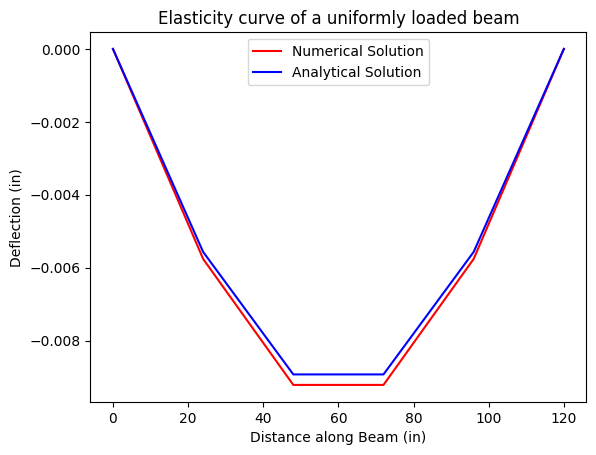

In [6]:
# convert units to either inches or feet
dx =  24       # inches
E  = 30000    # ksi
I  = 800      # in^4
w  = 1/12     # kip/inches
L  = 120    # inches
x = np.arange(0,L+dx,dx)   # xi's
b = dx*dx*(w*L*x-w*x*x)/(2*E*I) # RHS
b = b[1:-1] # internal nodes only
main = -2 * np.ones(len(b))
off1 = 1 * np.ones(len(b)-1)
A = np.diag(main) + np.diag(off1,-1) + np.diag(off1,1)
y = np.linalg.solve(A,b)
y = np.concatenate(([0], y, [0]), axis=0) # add BCs back in
# analytical solution
y_a = (w*L*x**3)/(12*E*I) - (w*x**4)/(24*E*I) -(w*x*L**3)/(24*E*I)
# report results in table or graph
plt.plot(x, y, 'r', label='Numerical Solution')
plt.plot(x, y_a, 'b', label='Analytical Solution')
plt.title('Elasticity curve of a uniformly loaded beam')
plt.xlabel('Distance along Beam (in)')
plt.ylabel('Deflection (in)')
plt.legend()
plt.show()

**Discussion of Results**

[The finite-difference approach solves the beam deflection equation by replacing derivatives with numerical approximations at discrete points along the beam. The beam is divided into evenly spaced nodes using a step size dx, and the second derivative in the beam equation is approximated using finite-difference formulas. What this does is convert the differential equation into a system of linear algebra equations that can be written in matrix form. Next the matrix equation Ay = b is solved using numerical methods to find the deflection values at each node along the beam.

The shooting method solves the same problem by converting the boundary value problem into an initial value problem. A guess is made for the unknown initial slope of the beam, and the differential equation is integrated across the beam length. What happens next is the result at the end of the beam is compared with the required boundary condition.  After that the guess is adjusted until the correct boundary condition is satisfied. Also both the finite-difference method and the shooting method produce results that closely match the analytical solution. What we see in the plot is the numerical finite-difference solution closely follows the analytical solution and this shows that the numerical method accurately approximates the true beam deflection.
]

## <font color='red'>**Problem 20.33**</font>

The following model is frequently used in environmental engineering to parameterize the effect of temperature $T$ (°C) on biochemical reaction rates $k$ (per day),

$k=k_{20}\theta^{T-20}$

where $k_{20}$ and $\theta$ are parameters. Use a transformation to linearize this equation. Then employ linear regression to estimate $k_{20}$ and $\theta$ and predict the reaction rate at $T=$ 17°C.

|    $T$ (°C)    |   6  |  12  |  18  | 24   | 30   |
|:-------------:|:----:|:----:|:----:|------|------|
| $k$ (per day) | 0.14 | 0.20 | 0.31 | 0.46 | 0.69 |

<font color='red'> **TL;DR**:
Explain how to linearize the equation above so that the data in the table can be used to estimate the values of the parameters $k_{20}$ and $\theta$. Create a program that estimates $k_{20}$ and $\theta$ (Hint: use the `stats.linregress()` function from the `scipy` package), plot $log(k)$ vs. $T-20$, and estimate the value for $k$ at $T=17°C$. Discuss how well the fitted parameters model the tabulated data.
</font>

### <font color='blue'>**Solution 20.33**</font>



Scipy function:
Slope: 0.06705012454831843
Intercept: -1.0447649951433045
r2: 0.9992777865256207


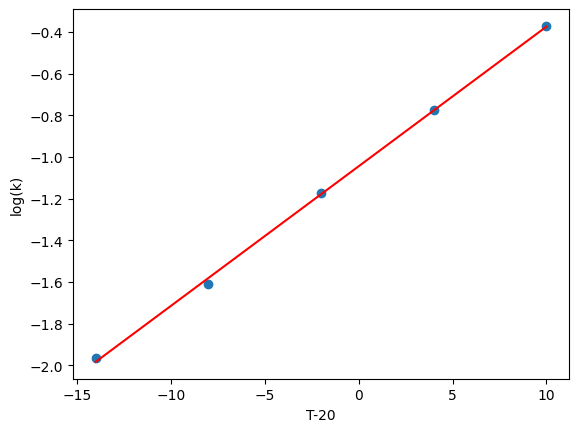

0.3517744783759334 1.0693490774707717
0.2876774566066509 day^-1


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# data
T = np.array([6, 12, 18, 24, 30])   # temperature (deg C)
k = np.array([0.14, 0.20, 0.31, 0.46, 0.69])   # reaction rate (1/day)

x = T - 20
y = np.log(k)

# linear regression
res = linregress(x, y)

print('Scipy function:')
print('Slope:', res.slope)
print('Intercept:', res.intercept)
print('r2:', res.rvalue**2)

# plot
plt.scatter(x, y)
plt.plot(x, res.intercept + res.slope * x, color='red')
plt.xlabel('T-20')
plt.ylabel('log(k)')
plt.show()

# convert back to original parameters
k20 = np.exp(res.intercept)
theta = np.exp(res.slope)

print(k20, theta)

# reaction rate at T = 17
rate_17 = k20 * theta**(17 - 20)
print(rate_17, 'day^-1')

**Discussion of Results**

[To linearize the equation, what we do is first take the natural log of both sides.  This gives ln(k) = ln(k20) + (T - 20) ln(theta) and this euqation now has the form of a straight line y = mx + b, where y = ln(k) and x = T-20.  The intercept of the line is ln(k20) and the slope is ln(theta).  By plotting ln(k) versus T - 20 and fitting a line using linear regression, the values of k20 and theta can be found by taking the exponential of the intercept and slope.

The fitted parameters match the data very well. What we see is that the data points lie very close to the regression line in the plot.  This shows that the linear model represents the relationship accurately.  Also we see that the coefficient of determination is r^2 = 0.9993, which is very close to 1 which means that the model explains almost all of the variation in the data.  Therefore this means the estimated values of k20 and theta provide an excellent fit to the measured reaction rates.
]